# Quantum Machine Learning with a TwoLocal Variational Classifier -- PennyLane

This notebook is a **PennyLane re-implementation** of [`../Parallel_QML.ipynb`](../Parallel_QML.ipynb),
which originally trains and evaluates a variational quantum classifier with **Qiskit**
on four 2-D binary-classification datasets (`checkerboard`, `circles`, `corners`,
`semicircles`), each available in 10 independent instances.

The model is identical to the original:
- a **ZZFeatureMap** encoder (Havlicek et al., `reps=2`, full entanglement) for the
  two input features, and
- a **TwoLocal** (`ry`, `rz`, `cz`, *full* entanglement, `reps=1`) variational ansatz,
  re-uploaded **4 times**, trained with **SPSA**.

Two circuit constructions are provided, exactly mirroring the Qiskit notebook:
- **Method 1** -- one circuit per data point (standard per-sample evaluation).
- **Method 2** -- all data points encoded in superposition through an index
  register (amplitude/QRAM-style batch encoding).

The gate-level circuits were reverse-engineered from Qiskit's `ZZFeatureMap` /
`TwoLocal` decompositions and verified to reproduce **bit-identical predictions**
from the Qiskit-trained parameters shipped in [`../results`](../results) -- see
[`verify_against_qiskit.py`](verify_against_qiskit.py).

All PennyLane-specific code lives in this folder ([`pennylane_implementation/`](.)):
[`qml_core.py`](qml_core.py) (circuits/classifiers) and [`train.py`](train.py)
(a small framework-agnostic SPSA optimizer). The `multiclass/` folder is a separate,
independent experiment and is **not** covered here.

## How to use this notebook
1. Edit the **Configuration** cell below.
2. *Run All*. Everything else (loading, training/loading results, plots, metrics)
   happens automatically and is displayed inline.

> **Tip:** Set `MODE = "load"` to load the parameters trained by the original
> Qiskit notebook and re-evaluate them with the PennyLane circuits (a live
> cross-framework consistency check), or `MODE = "train"` to train from scratch
> using PennyLane + SPSA.

## 1. Configuration  *(the only cell you normally edit)*

In [22]:
# ============================ USER SETTINGS ============================
# Pick the dataset family:  "checkerboard" | "circles" | "corners" | "semicircles"
DATASET_TYPE = "checkerboard"

# Pick the instance:  an integer from 1 to 10
DATASET_NUM = 6

# What to do:
#   "load"  -> load the Qiskit-trained parameters shipped in ../results and
#              re-evaluate them with the PennyLane circuits (fast; also acts as
#              a cross-framework correctness check)
#   "train" -> train the PennyLane circuits from scratch with SPSA (slower)
MODE = "train"

# Which circuit construction(s) to run / display:
#   [1]    -> only Method 1 (one circuit per sample)
#   [2]    -> only Method 2 (all samples in superposition)
#   [1, 2] -> both, shown side by side
METHODS = [1, 2]

# --- settings used only when MODE == "train" ---
MAXITER = 500        # SPSA iterations. Method 1 is fast (batched -> a few seconds
                    # total). Method 2 is slow: ~4s/circuit evaluation, 3
                    # evaluations/iteration -> roughly 4 * 3 * MAXITER seconds
                    # (e.g. ~10 min for 50 iterations, ~20 min for 100).
SEED    = 42        # random seed for the initial parameters (reproducibility)

# --- visualization ---
PLOT_DECISION_BOUNDARY = False   # draw the learned decision boundary (a bit slower)
GRID_RES = 60                    # resolution of the decision-boundary grid
# ======================================================================

assert DATASET_TYPE in {"checkerboard", "circles", "corners", "semicircles"}
assert 1 <= DATASET_NUM <= 10
assert MODE in {"load", "train"}
assert all(m in (1, 2) for m in METHODS) and len(METHODS) >= 1
print(f"Dataset : {DATASET_TYPE} / dataset{DATASET_NUM}")
print(f"Mode    : {MODE}   |   Method(s): {METHODS}")

Dataset : checkerboard / dataset6
Mode    : train   |   Method(s): [1, 2]


## 2. Imports

In [23]:
import os
import json
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

sys.path.insert(0, os.path.abspath("."))
from qml_core import (
    Method1Classifier, Method2Classifier, OpaqueBlock,
    zz_feature_map_qfunc, two_local_block, two_local_num_params,
)
from train import OptimizerLog, spsa_minimize

warnings.filterwarnings("ignore")
np.random.seed(SEED)
print("PennyLane version:", qml.__version__)

PennyLane version: 0.40.0


## 3. Load the selected dataset

Train data : (128, 2),  labels: (128,)
Test  data : (64, 2),  labels: (64,)


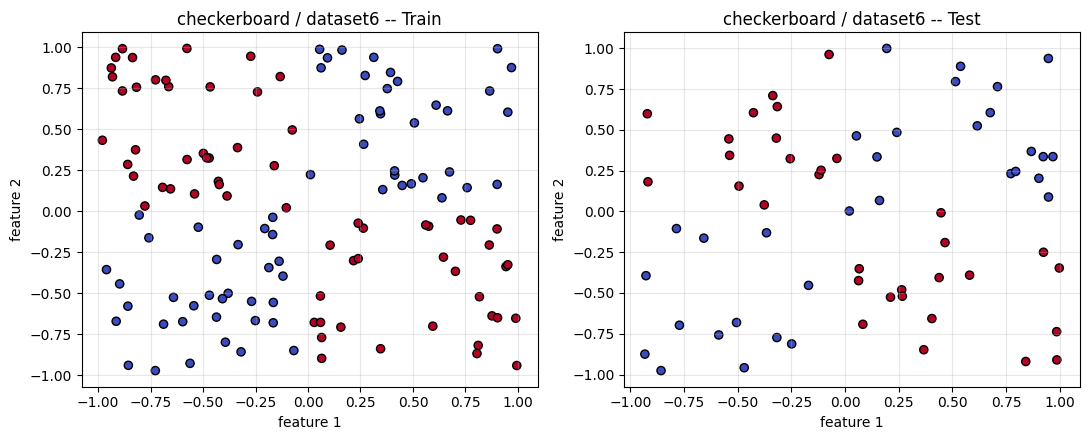

In [24]:
DATA_DIR    = os.path.join("..", "datasets", DATASET_TYPE, f"dataset{DATASET_NUM}")
RESULTS_DIR = os.path.join("..", "results",  DATASET_TYPE, f"dataset{DATASET_NUM}")

train_data   = pd.read_csv(os.path.join(DATA_DIR, "train_data")).to_numpy()
train_labels = pd.read_csv(os.path.join(DATA_DIR, "train_labels")).to_numpy().flatten()
test_data    = pd.read_csv(os.path.join(DATA_DIR, "test_data")).to_numpy()
test_labels  = pd.read_csv(os.path.join(DATA_DIR, "test_labels")).to_numpy().flatten()

print(f"Train data : {train_data.shape},  labels: {train_labels.shape}")
print(f"Test  data : {test_data.shape},  labels: {test_labels.shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, X, y, name in [(axes[0], train_data, train_labels, "Train"),
                       (axes[1], test_data,  test_labels,  "Test")]:
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=35)
    ax.set_title(f"{DATASET_TYPE} / dataset{DATASET_NUM} -- {name}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Quantum-circuit hyperparameters

In [25]:
num_reupload = 4
num_features = train_data.shape[1]

clf1 = Method1Classifier(n_features=num_features, num_reupload=num_reupload)
clf2 = Method2Classifier(n_features=num_features, num_reupload=num_reupload,
                          num_data=len(train_data)) if 2 in METHODS else None

num_parameters = clf1.num_parameters
num_register = clf2.n_index if clf2 is not None else int(np.log2(len(train_data)))

print(f"Re-uploads        : {num_reupload}")
print(f"Feature qubits    : {num_features}")
print(f"Index register    : {num_register} qubits  (Method 2)")
print(f"Trainable params  : {num_parameters}")
print(f"Method 1 device   : {clf1.dev.short_name if hasattr(clf1.dev, 'short_name') else clf1.dev.name}")
if clf2 is not None:
    print(f"Method 2 device   : {clf2.dev.short_name if hasattr(clf2.dev, 'short_name') else clf2.dev.name}")

Re-uploads        : 4
Feature qubits    : 2
Index register    : 7 qubits  (Method 2)
Trainable params  : 32
Method 1 device   : default.qubit
Method 2 device   : lightning.qubit


## 5. Circuit definitions

**Method 1** builds one circuit per data point. **Method 2** encodes the whole
dataset in superposition using an index register: it puts the index register
into a uniform superposition, then -- for every training point `i` -- applies
the (re-uploaded) encoder+ansatz controlled on the index register reading `i`.
The classification readout is the marginal probability of qubit 0 in *both*
methods, but Method 2 only "knows" the labels because the training set is
pre-sorted (all label-0 points first, all label-1 points last): flipping a
dedicated label qubit whenever (top index bit, predicted qubit) agree turns
"probability of a correct batch prediction" into a single readout qubit,
without ever passing the labels into the circuit explicitly. This exactly
mirrors `qc2()` in the original Qiskit notebook.

The two encoder/variational sub-circuits below are drawn for reference.

ZZFeatureMap encoder (reps=2, full entanglement):


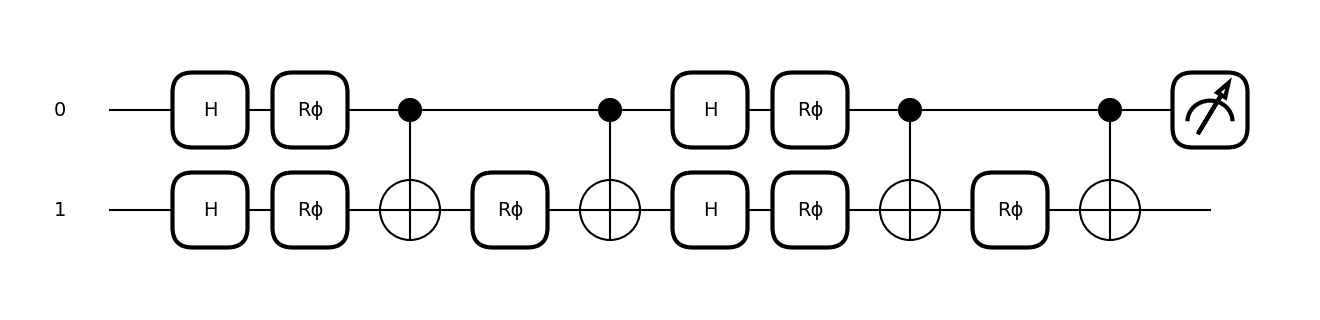

TwoLocal ansatz (ry, rz, cz, full entanglement, reps=1):


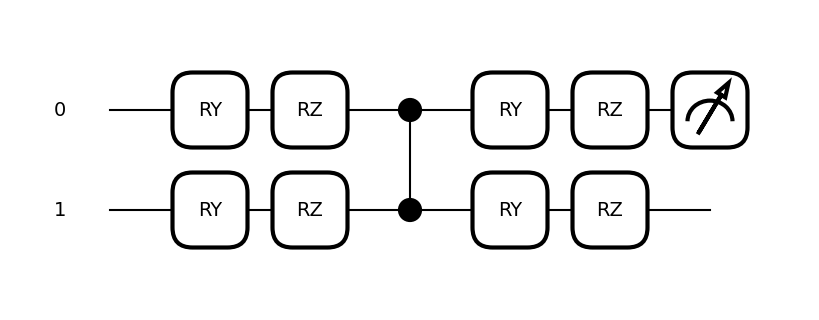

In [26]:
# Reference drawings of the building blocks (single circuit, no re-upload)
example_data = train_data[0]
example_params = np.zeros(two_local_num_params(num_features, reps=1))

dev_ref = qml.device("default.qubit", wires=num_features)

@qml.qnode(dev_ref)
def _draw_encoder():
    zz_feature_map_qfunc(example_data, list(range(num_features)), reps=2)
    return qml.probs(wires=0)

@qml.qnode(dev_ref)
def _draw_ansatz():
    two_local_block(example_params, list(range(num_features)), reps=1)
    return qml.probs(wires=0)

print("ZZFeatureMap encoder (reps=2, full entanglement):")
qml.draw_mpl(_draw_encoder)()
plt.show()

print("TwoLocal ansatz (ry, rz, cz, full entanglement, reps=1):")
qml.draw_mpl(_draw_ansatz)()
plt.show()

=== Method 1 circuit ===


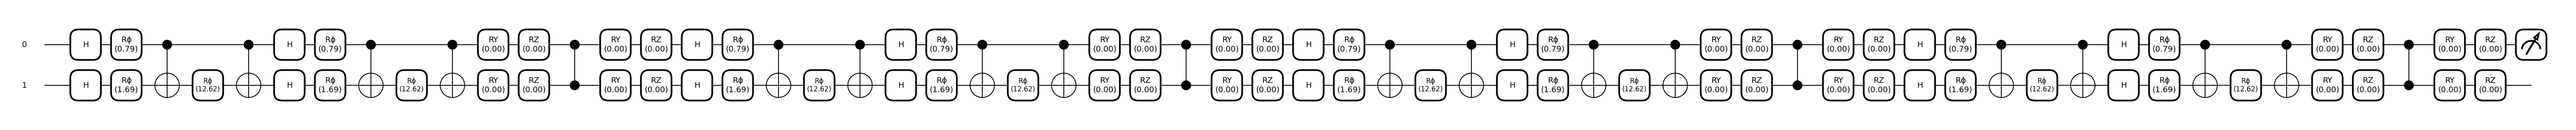

In [27]:
# Method 1: the actual per-sample circuit (compact enough to draw in full)
if 1 in METHODS:
    print("=== Method 1 circuit ===")
    qml.draw_mpl(clf1._qnode, decimals=2)(train_data[0], np.zeros(num_parameters))
    plt.show()

=== Method 2 circuit (schematic; 'Enc' hides one controlled block per training point, 128 of them) ===


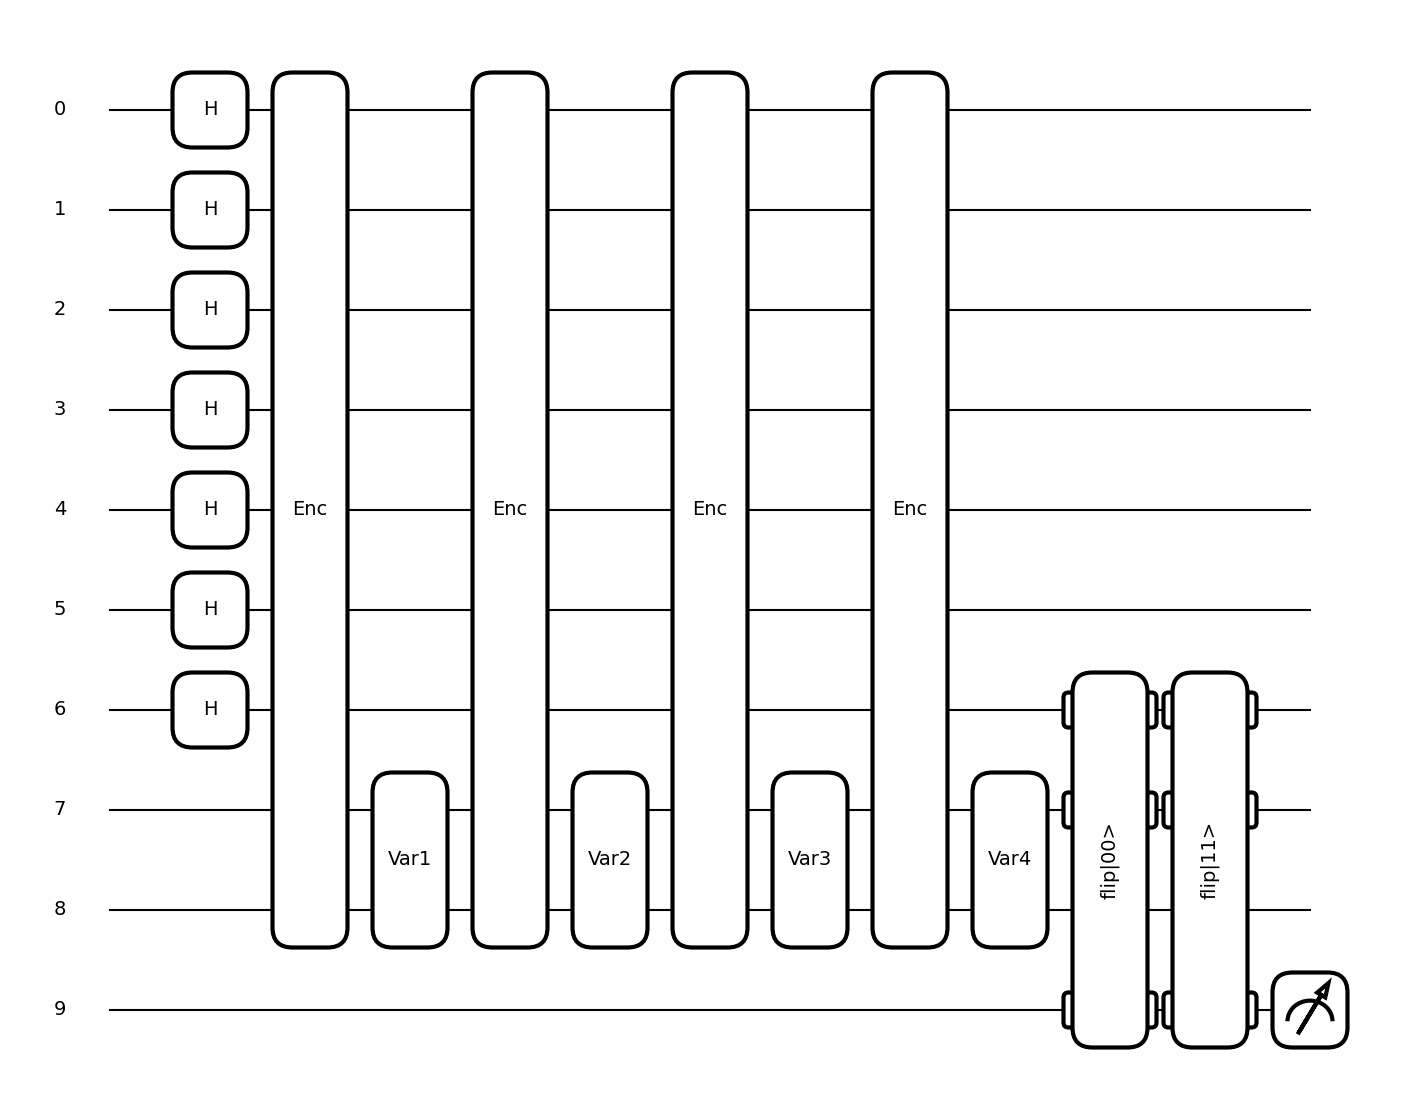

In [28]:
# Method 2: schematic circuit. The real circuit applies one controlled
# encoder block per training point (len(train_data) of them per re-upload --
# far too many to render legibly), so -- exactly like the original notebook's
# qc2(), which bundles the whole encoder into a single named Qiskit Gate via
# .to_gate() -- we draw it with each block collapsed into one labeled box.
if 2 in METHODS:
    print("=== Method 2 circuit (schematic; 'Enc' hides one controlled block per "
          f"training point, {len(train_data)} of them) ===")

    dev_schematic = qml.device("default.qubit", wires=clf2.total_wires)

    @qml.qnode(dev_schematic)
    def _draw_method2():
        for w in clf2.index_wires:
            qml.Hadamard(wires=w)
        for layer in range(num_reupload):
            OpaqueBlock(wires=clf2.index_wires + clf2.feature_wires, label_text="Enc")
            OpaqueBlock(wires=clf2.feature_wires, label_text=f"Var{layer + 1}")
        OpaqueBlock(wires=[clf2.index_wires[-1], clf2.feature_wires[0], clf2.label_wire],
                    label_text="flip|00>")
        OpaqueBlock(wires=[clf2.index_wires[-1], clf2.feature_wires[0], clf2.label_wire],
                    label_text="flip|11>")
        return qml.probs(wires=clf2.label_wire)

    qml.draw_mpl(_draw_method2, fold=-1)()
    plt.show()

## 6. Training / evaluation functions

Accuracy is always measured with the Method-1 per-sample circuit (`clf1`), so
trained parameters from either method are evaluated consistently -- exactly as
in the original notebook.

In [29]:
def performance_evaluation(data, labels, variational):
    '''Return (accuracy, predictions) using the Method-1 read-out.'''
    return clf1.performance_evaluation(data, labels, variational)


def cost_function_1(variational):
    return clf1.cost(train_data, train_labels, variational)


def cost_function_2(variational):
    return clf2.cost(train_data, variational)


def make_evaluate_fn():
    def evaluate_fn(variational):
        tr, _ = performance_evaluation(train_data, train_labels, variational)
        te, _ = performance_evaluation(test_data, test_labels, variational)
        return tr, te
    return evaluate_fn

## 7. Run training **or** load the saved results

Loops over every method in `METHODS` and fills a `results` dictionary --
`results[m]["history"]` and `results[m]["final_params"]` -- regardless of
whether you trained live (`MODE="train"`) or loaded the Qiskit-trained
parameters (`MODE="load"`). All later cells iterate over the same `METHODS`.

In [30]:
results = {}

for METHOD in METHODS:
    print(f"\n########## Method {METHOD} ##########")
    if MODE == "train":
        print(f"Training Method {METHOD} with SPSA ({MAXITER} iterations)...\n")
        np.random.seed(SEED)
        initial_point = np.random.uniform(-np.pi, np.pi, size=num_parameters)

        objective = cost_function_1 if METHOD == 1 else cost_function_2
        log = OptimizerLog(make_evaluate_fn())

        t0 = time.time()
        final_params, final_cost = spsa_minimize(
            objective, initial_point, maxiter=MAXITER, log=log, seed=SEED)
        elapsed = time.time() - t0

        history = {
            "costs": log.costs,
            "train_accuracies": log.train_accuracies,
            "test_accuracies": log.test_accuracies,
            "stepsizes": log.stepsizes,
            "final_cost": float(final_cost),
        }
        print(f"\nDone in {elapsed:.1f}s. Final cost = {final_cost:.6f}")

    else:  # MODE == "load"
        json_path = os.path.join(RESULTS_DIR, f"method{METHOD}.json")
        print(f"Loading Qiskit-trained results from: {json_path}")
        with open(json_path, encoding="utf-8") as f:
            saved = json.load(f)
        th = saved["training_history"]
        fr = saved["final_results"]
        history = {
            "costs": th["costs"],
            "train_accuracies": th["train_accuracies"],
            "test_accuracies": th["test_accuracies"],
            "stepsizes": th["stepsizes"],
            "final_cost": fr["final_cost"],
        }
        final_params = np.array(fr["final_parameters"])
        print(f"Loaded {len(history['costs'])} iterations "
              f"(optimizer: {saved['experiment_info']['optimizer']})")

        # Cross-framework check: re-evaluate the Qiskit-trained parameters with
        # the PennyLane circuits and confirm the predictions agree exactly.
        pl_test_acc, pl_test_pred = performance_evaluation(test_data, test_labels, final_params)
        qiskit_test_pred = fr["test_predictions"]
        agreement = np.mean([int(a == b) for a, b in zip(pl_test_pred, qiskit_test_pred)])
        print(f"PennyLane re-evaluation: test_acc={pl_test_acc:.4f} "
              f"(qiskit reported {fr['final_test_accuracy']:.4f}), "
              f"prediction agreement with Qiskit = {agreement:.4f}")

    results[METHOD] = {"history": history, "final_params": final_params}


########## Method 1 ##########
Training Method 1 with SPSA (500 iterations)...

 Iter   1: loss=0.6480  train_acc=0.6172  test_acc=0.5469  step=0.6134
 Iter   2: loss=0.6346  train_acc=0.6641  test_acc=0.5938  step=0.6063
 Iter   3: loss=0.6402  train_acc=0.6562  test_acc=0.5938  step=0.5994
 Iter   4: loss=0.6294  train_acc=0.6719  test_acc=0.6406  step=0.5927
 Iter   5: loss=0.6340  train_acc=0.6719  test_acc=0.6875  step=0.5862
 Iter   6: loss=0.6385  train_acc=0.6562  test_acc=0.7031  step=0.5799
 Iter   7: loss=0.6382  train_acc=0.6562  test_acc=0.6875  step=0.5737
 Iter   8: loss=0.6454  train_acc=0.6562  test_acc=0.7188  step=0.5677
 Iter   9: loss=0.6414  train_acc=0.6797  test_acc=0.6719  step=0.5619
 Iter  10: loss=0.6328  train_acc=0.6875  test_acc=0.6875  step=0.5563
 Iter  11: loss=0.6300  train_acc=0.6953  test_acc=0.7344  step=0.5508
 Iter  12: loss=0.6227  train_acc=0.6953  test_acc=0.7656  step=0.5454
 Iter  13: loss=0.6188  train_acc=0.6953  test_acc=0.7500  step=0.5

## 8. Training curves

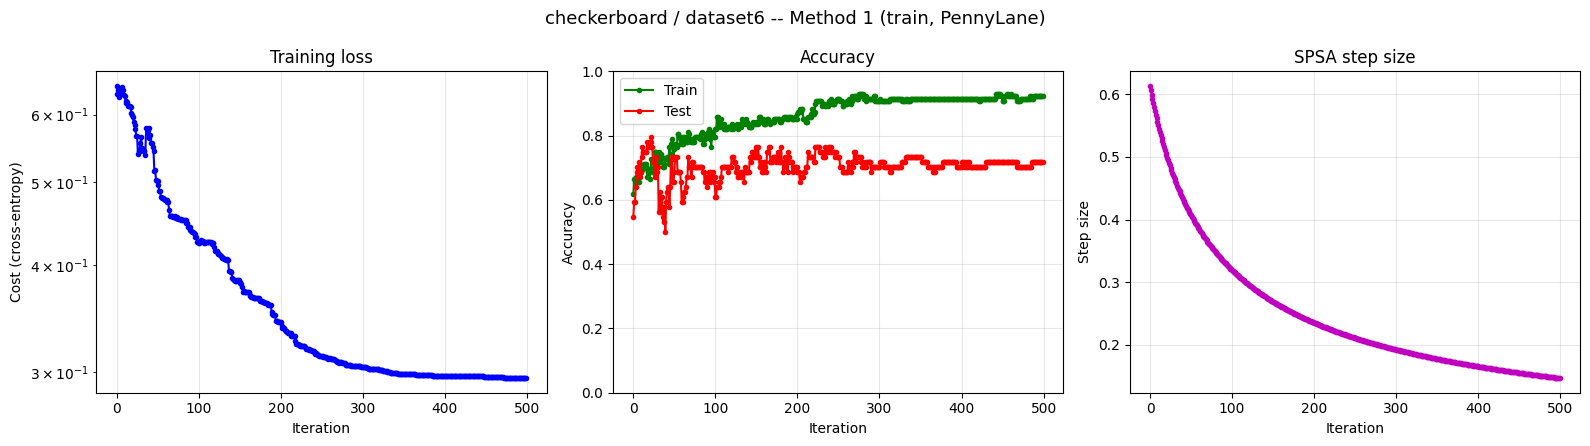

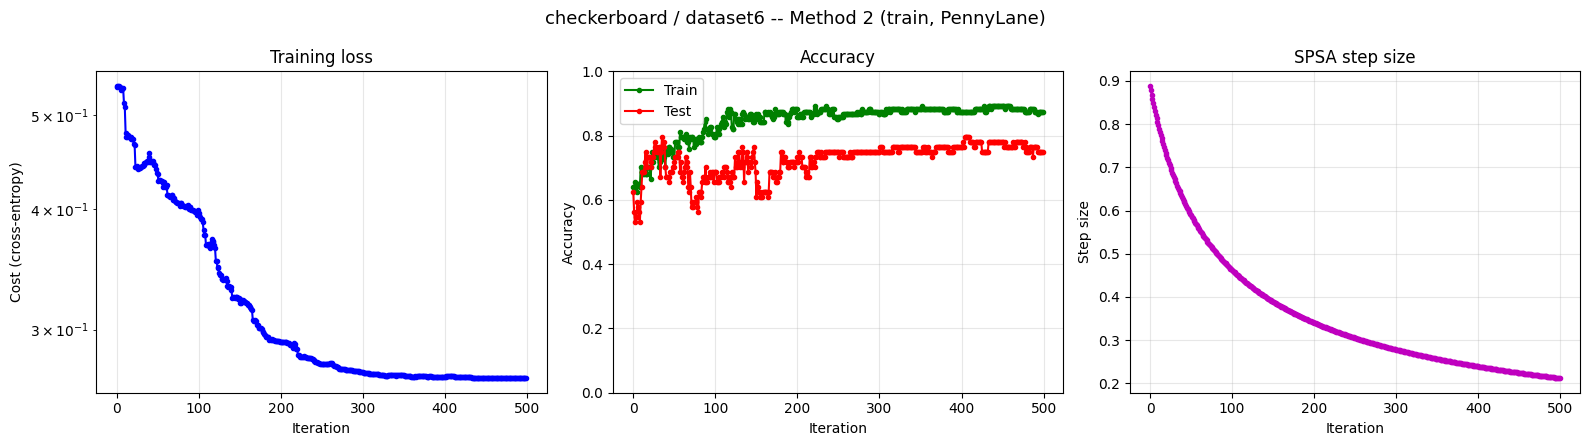

In [31]:
for METHOD in METHODS:
    history = results[METHOD]["history"]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(history["costs"], 'b-o', ms=3)
    ax[0].set_yscale('log'); ax[0].set_title("Training loss")
    ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Cost (cross-entropy)")
    ax[0].grid(alpha=0.3)

    ax[1].plot(history["train_accuracies"], 'g-o', ms=3, label="Train")
    ax[1].plot(history["test_accuracies"],  'r-o', ms=3, label="Test")
    ax[1].set_ylim(0, 1); ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Accuracy")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    ax[2].plot(history["stepsizes"], 'm-o', ms=3)
    ax[2].set_title("SPSA step size")
    ax[2].set_xlabel("Iteration"); ax[2].set_ylabel("Step size")
    ax[2].grid(alpha=0.3)

    fig.suptitle(f"{DATASET_TYPE} / dataset{DATASET_NUM} -- Method {METHOD} ({MODE}, PennyLane)",
                 fontsize=13)
    plt.tight_layout(); plt.show()

## 9. Predictions and decision boundary

Predictions are computed with the trained parameters. The decision boundary is
evaluated on a grid using the Method-1 read-out (set `PLOT_DECISION_BOUNDARY=False`
in the config to skip the slower grid evaluation).

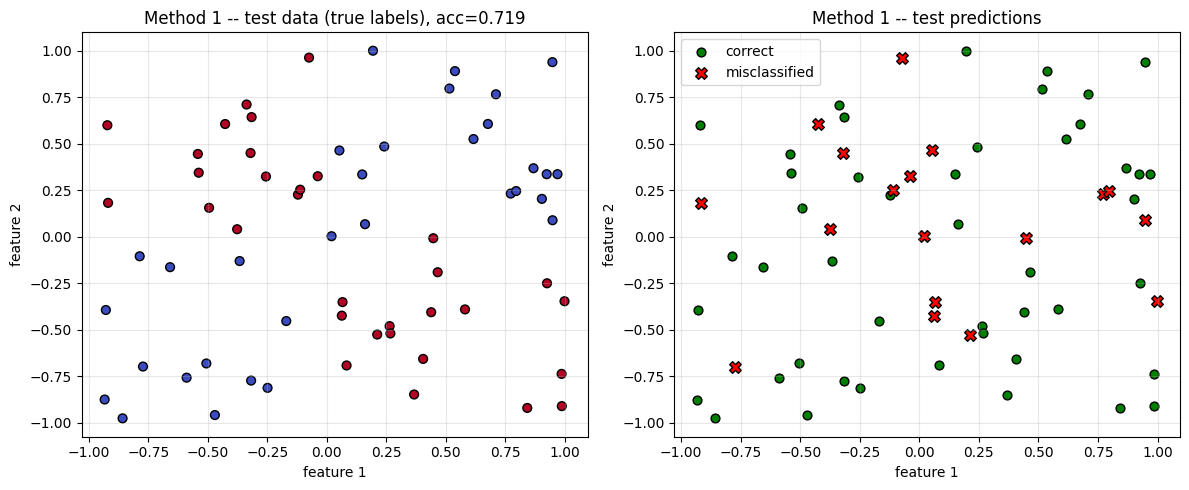

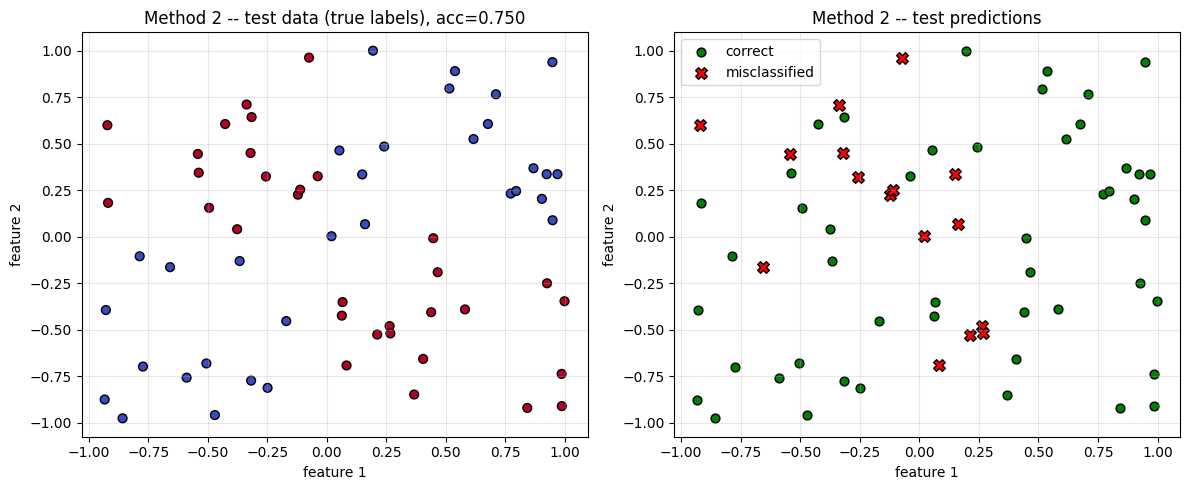

In [32]:
if PLOT_DECISION_BOUNDARY:
    allX = np.vstack([train_data, test_data])
    pad = 0.2
    x_min, x_max = allX[:, 0].min() - pad, allX[:, 0].max() + pad
    y_min, y_max = allX[:, 1].min() - pad, allX[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, GRID_RES),
                         np.linspace(y_min, y_max, GRID_RES))
    grid = np.c_[xx.ravel(), yy.ravel()]

for METHOD in METHODS:
    final_params = results[METHOD]["final_params"]
    final_train_acc, train_pred = performance_evaluation(train_data, train_labels, final_params)
    final_test_acc,  test_pred  = performance_evaluation(test_data,  test_labels,  final_params)
    test_pred = np.array(test_pred)
    results[METHOD]["final_train_acc"] = final_train_acc
    results[METHOD]["final_test_acc"]  = final_test_acc

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if PLOT_DECISION_BOUNDARY:
        print(f"Method {METHOD}: evaluating {GRID_RES}x{GRID_RES} decision-boundary grid...")
        probs = clf1.classification_probability(grid, final_params)
        zz = np.array([p.get('1', 0) for p in probs]).reshape(xx.shape)
        for ax in axes:
            ax.contourf(xx, yy, zz, levels=20, cmap="coolwarm", alpha=0.5)
            ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=1.5)

    ax = axes[0]
    ax.scatter(test_data[:, 0], test_data[:, 1], c=test_labels, cmap="coolwarm",
               edgecolors="k", s=40)
    ax.set_title(f"Method {METHOD} -- test data (true labels), acc={final_test_acc:.3f}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2"); ax.grid(alpha=0.3)

    ax = axes[1]
    correct = test_pred == test_labels
    ax.scatter(test_data[correct, 0], test_data[correct, 1], c="green",
               edgecolors="k", s=40, label="correct")
    ax.scatter(test_data[~correct, 0], test_data[~correct, 1], c="red",
               marker="X", edgecolors="k", s=70, label="misclassified")
    ax.set_title(f"Method {METHOD} -- test predictions")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

## 10. Final performance summary

In [33]:
print(f"Dataset: {DATASET_TYPE} / dataset{DATASET_NUM}    Mode: {MODE}    Framework: PennyLane\n")

rows = []
for METHOD in METHODS:
    h = results[METHOD]["history"]
    rows.append({
        "method": METHOD,
        "final_train_acc": round(results[METHOD]["final_train_acc"], 4),
        "final_test_acc":  round(results[METHOD]["final_test_acc"], 4),
        "best_test_acc":   round(max(h["test_accuracies"]), 4),
        "best_train_acc":  round(max(h["train_accuracies"]), 4),
        "final_cost":      round(h["final_cost"], 6),
    })

summary_methods = pd.DataFrame(rows).set_index("method")
display(summary_methods)

Dataset: checkerboard / dataset6    Mode: train    Framework: PennyLane



,final_train_acc,final_test_acc,best_test_acc,best_train_acc,final_cost
method,,,,,
1,0.9219,0.7188,0.7969,0.9297,0.295252
2,0.8750,0.7500,0.7969,0.8906,0.267282


## 11. (Optional) Compare all 10 instances of the selected family

A quick aggregate view across `dataset1` ... `dataset10` for the chosen
`DATASET_TYPE` and `METHOD`, read from the Qiskit-saved results (the same
`method{1,2}.json` files used by the original notebook -- the training-history
numbers are framework-agnostic). This does not depend on the single-dataset
selection above.


===== checkerboard -- Method 1 (all 10 instances, Qiskit-trained params) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.8281,0.8438,0.8750,0.3823
2,0.7969,0.7969,0.8828,0.3448
3,0.7344,0.7812,0.7891,0.4231
4,0.7969,0.7969,0.8438,0.4027
5,0.6875,0.7188,0.8672,0.3892
6,0.8438,0.8438,0.9297,0.3638
7,0.7344,0.7344,0.8750,0.4203
8,0.7500,0.7969,0.8750,0.3662
9,0.7969,0.8438,0.8125,0.3999


Mean final test accuracy: 0.7750 +/- 0.0478


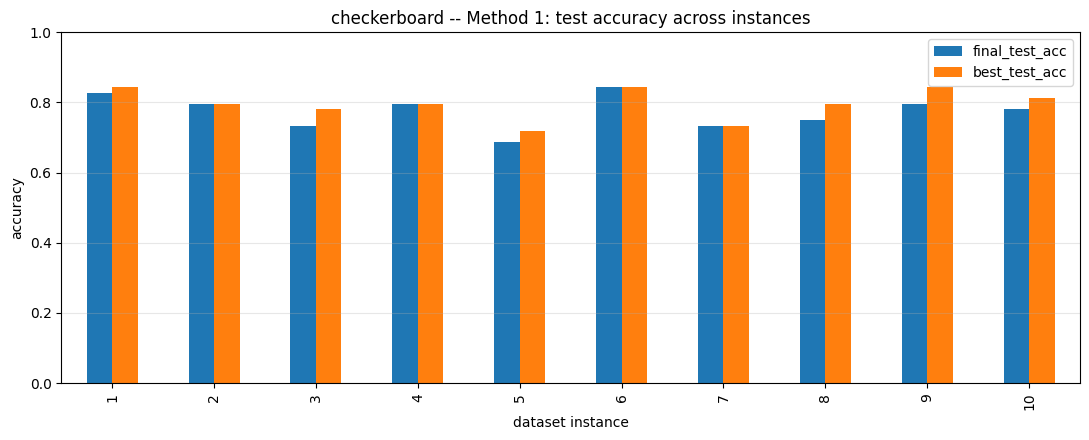


===== checkerboard -- Method 2 (all 10 instances, Qiskit-trained params) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.7031,0.7188,0.8203,0.3349
2,0.8281,0.8750,0.8203,0.3175
3,0.7188,0.7500,0.8438,0.3391
4,0.7656,0.8125,0.8828,0.3207
5,0.6875,0.7188,0.8828,0.3292
6,0.7031,0.8281,0.8594,0.3212
7,0.7500,0.7969,0.8516,0.3456
8,0.7969,0.7969,0.9141,0.2651
9,0.7656,0.7969,0.8906,0.3255


Mean final test accuracy: 0.7578 +/- 0.0572


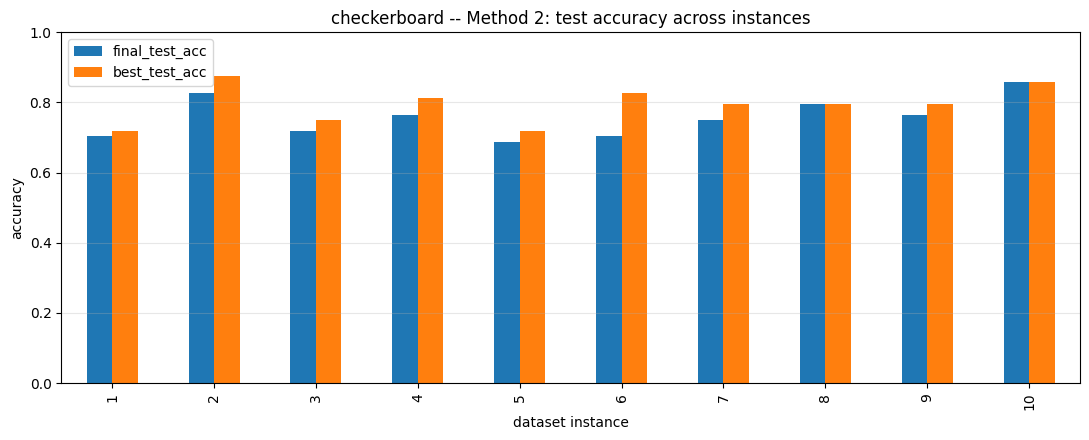

In [34]:
for METHOD in METHODS:
    rows = []
    for n in range(1, 11):
        p = os.path.join("..", "results", DATASET_TYPE, f"dataset{n}", f"method{METHOD}.json")
        if not os.path.exists(p):
            continue
        with open(p, encoding="utf-8") as f:
            s = json.load(f)
        fr, th = s["final_results"], s["training_history"]
        rows.append({
            "dataset": n,
            "final_test_acc": fr["final_test_accuracy"],
            "best_test_acc":  max(th["test_accuracies"]),
            "final_train_acc": fr["final_train_accuracy"],
            "final_cost": fr["final_cost"],
        })

    summary = pd.DataFrame(rows).set_index("dataset")
    print(f"\n===== {DATASET_TYPE} -- Method {METHOD} (all 10 instances, Qiskit-trained params) =====")
    display(summary.round(4))
    print(f"Mean final test accuracy: "
          f"{summary['final_test_acc'].mean():.4f} +/- {summary['final_test_acc'].std():.4f}")

    ax = summary[["final_test_acc", "best_test_acc"]].plot.bar(figsize=(11, 4.5))
    ax.set_title(f"{DATASET_TYPE} -- Method {METHOD}: test accuracy across instances")
    ax.set_xlabel("dataset instance"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()